# Part 2: Implementation Tasks

# Task 1: Inspection


Look at the images in both datasets, and briefly explain if you observe any systematic differences
between images in one dataset vs. the other.

Overall, DBI represents a controlled, studio-quality dataset, while SDD portrays more dynamic, real-world scenarios with varied backgrounds and contexts.

The DBI dataset consists of professional, high-quality photos where dogs are the central focus, often set against plain white or neutral backgrounds with no distractions. The images have consistent lighting and clear detail, making them ideal for studies requiring precision, like breed identification. In contrast, the SDD dataset features more candid, real-world images where dogs are shown in diverse environments, such as on the beach, in cars, or with people. These photos often include other elements or subjects, capturing natural interactions and daily activities, making them appear more like images sourced from social media or personal collections.

In [1]:
import os
import zipfile
import torch
import pandas as pd
import numpy as np
import torchvision
import torch.nn as nn
from torch.utils.data import Dataset, random_split, DataLoader
import matplotlib.pyplot as plt
import torch.nn.functional as F
from torchvision.utils import make_grid
from torchvision.datasets import ImageFolder
import torchvision.transforms as transforms
import torchvision.models as models
from PIL import Image
from collections import OrderedDict
from tqdm.notebook import tqdm

In [2]:
# load dataset
DBIdataset = ImageFolder("/content/drive/MyDrive/csc420/DBIsubset")
SDDdataset = ImageFolder("/content/drive/MyDrive/csc420/SDDsubset")
print(len(DBIdataset))
print(len(DBIdataset.classes))
print(len(SDDdataset))
print(len(SDDdataset.classes))

646
7
1233
7


In [3]:
# check breeds for both dataset
breeds_dbi = []
breeds_sdd = []
for n in DBIdataset.classes:
    breeds_dbi.append(n)
for n in SDDdataset.classes:
    breeds_sdd.append(n)

print(breeds_dbi)
print(breeds_sdd)
breeds = breeds_dbi

['bernese_mountain_dog', 'border_collie', 'chihuahua', 'golden_retriever', 'labrador_retriever', 'pug', 'siberian_husky']
['bernese_mountain_dog', 'border_collie', 'chihuahua', 'golden_retriever', 'labrador_retriever', 'pug', 'siberian_husky']


In [4]:
# DBI dataset
random_seed = 45
torch.manual_seed(random_seed);

test_pct = 0.3
test_size = int(len(DBIdataset)*test_pct)
dataset_size = len(DBIdataset) - test_size

val_pct = 0.1
val_size = int(dataset_size*val_pct)
train_size = dataset_size - val_size
train_size, val_size, test_size

(408, 45, 193)

In [5]:
# SDD dataset
random_seed = 45
torch.manual_seed(random_seed);

test_pct = 0.3
sdd_test_size = int(len(SDDdataset)*test_pct)
sdd_dataset_size = len(SDDdataset) - sdd_test_size

val_pct = 0.1
sdd_val_size = int(sdd_dataset_size*val_pct)
sdd_train_size = sdd_dataset_size - sdd_val_size


sdd_train_size, sdd_val_size, sdd_test_size

(778, 86, 369)

In [6]:
train_ds, val_ds, test_ds = random_split(DBIdataset, [train_size, val_size, test_size])
print(train_ds[6])

(<PIL.Image.Image image mode=RGB size=1600x1200 at 0x78DEA798ED40>, 3)


In [7]:
# for sdd dataset
sdd_train_ds, sdd_val_ds, sdd_test_ds = random_split(SDDdataset, [sdd_train_size, sdd_val_size, sdd_test_size])
len(sdd_train_ds), len(sdd_val_ds), len(sdd_test_ds)

(778, 86, 369)

bernese_mountain_dog
<class 'PIL.Image.Image'>


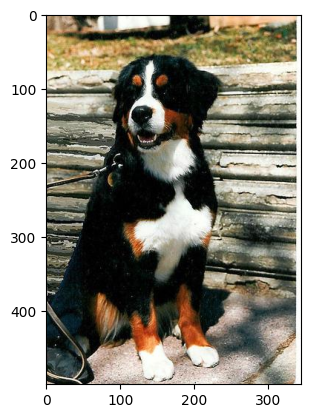

In [8]:
img, label = sdd_train_ds[3]
print(DBIdataset.classes[label])
plt.imshow(img)
print(type(img))

In [9]:
class DogBreedDataset(Dataset):

    def __init__(self, ds, transform=None):
        self.ds = ds
        self.transform = transform

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, idx):
        img, label = self.ds[idx]
        if self.transform:
            img = self.transform(img)
            return img, label

In [10]:
imagenet_stats = ([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])

train_transform = transforms.Compose([
#    transforms.Resize((224, 224)),
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224, padding=4, padding_mode='reflect'),
    transforms.RandomHorizontalFlip(p=0.3),
    transforms.RandomRotation(degrees=30),
    transforms.ToTensor(),
#    transforms.Normalize(*imagenet_stats, inplace=True)

])


val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
#    transforms.Normalize(*imagenet_stats, inplace=True)
])

test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
#    transforms.Normalize(*imagenet_stats, inplace=True)
])

In [11]:
train_dataset = DogBreedDataset(train_ds, train_transform)
val_dataset = DogBreedDataset(val_ds, val_transform)
test_dataset = DogBreedDataset(test_ds, test_transform)
dbi_dataset = DogBreedDataset(DBIdataset, test_transform)

sdd_train_dataset = DogBreedDataset(sdd_train_ds, train_transform)
sdd_val_dataset = DogBreedDataset(sdd_val_ds, val_transform)
sdd_test_dataset = DogBreedDataset(sdd_test_ds, test_transform)
sdd_dataset = DogBreedDataset(SDDdataset, test_transform)


0


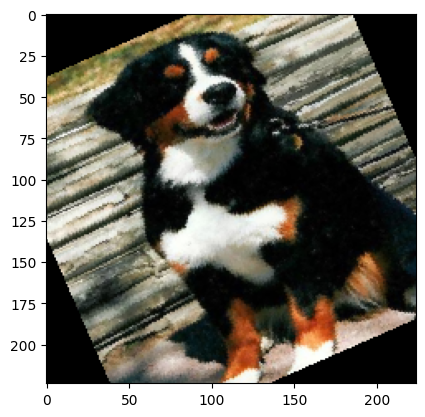

In [12]:
img, label = sdd_train_dataset[3]
print(label)
plt.imshow(img.permute(1,2,0))

In [13]:
batch_size =64

# DBI dataloaders
dbi_train_dl = DataLoader(train_dataset, batch_size, shuffle=True, num_workers=2, pin_memory=True)
dbi_val_dl = DataLoader(val_dataset, batch_size*2, num_workers=2, pin_memory=True)
dbi_test_dl = DataLoader(test_dataset, batch_size*2, num_workers=2, pin_memory=True)
DBI_dl = DataLoader(dbi_dataset, batch_size*2, num_workers=2, pin_memory=True)


In [14]:
# SDD dataloaders
sdd_train_dl = DataLoader(sdd_train_dataset, batch_size, shuffle=True, num_workers=2, pin_memory=True)
sdd_val_dl = DataLoader(sdd_val_dataset, batch_size*2, num_workers=2, pin_memory=True)
sdd_test_dl = DataLoader(sdd_test_dataset, batch_size*2, num_workers=2, pin_memory=True)
SDD_dl = DataLoader(sdd_dataset, batch_size*2, num_workers=2, pin_memory=True)

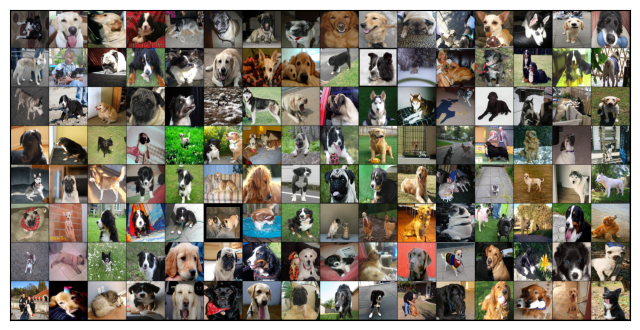

In [15]:
def show_batch(dl):
    for img, lb in dl:
        fig, ax = plt.subplots(figsize=(8, 8))
        ax.set_xticks([]); ax.set_yticks([])
        ax.imshow(make_grid(img.cpu(), nrow=16).permute(1,2,0))
        break
show_batch(sdd_test_dl)

In [16]:
def accuracy(outputs, labels):
    _, preds = torch.max(outputs, dim=1)
    return torch.tensor(torch.sum(preds == labels).item() / len(preds))

In [17]:
class ImageClassificationBase(nn.Module):
    # training step
    def training_step(self, batch):
        img, targets = batch
        out = self(img)
        loss = F.nll_loss(out, targets)
        return loss

    # validation step
    def validation_step(self, batch):
        img, targets = batch
        out = self(img)
        loss = F.nll_loss(out, targets)
        acc = accuracy(out, targets)
        return {'val_acc':acc.detach(), 'val_loss':loss.detach()}

    # validation epoch end
    def validation_epoch_end(self, outputs):
        batch_losses = [x['val_loss'] for x in outputs]
        epoch_loss = torch.stack(batch_losses).mean()
        batch_accs = [x['val_acc'] for x in outputs]
        epoch_acc = torch.stack(batch_accs).mean()
        return {'val_loss':epoch_loss.item(), 'val_acc':epoch_acc.item()}

    # print result end epoch
    def epoch_end(self, epoch, result):
        print("Epoch [{}] : train_loss: {:.4f}, val_loss: {:.4f}, val_acc: {:.4f}".format(epoch, result["train_loss"], result["val_loss"], result["val_acc"]))


In [18]:
def get_default_device():
    if torch.cuda.is_available():
        return torch.device('cuda')
    else:
        return torch.device('cpu')

def to_device(data, device):
    if isinstance(data, (list, tuple)):
        return [to_device(d, device) for d in data]
    else:
        return data.to(device, non_blocking=True)

In [19]:
class DeviceDataLoader:
    def __init__(self, dl, device):
        self.dl = dl
        self.device = device

    def __len__(self):
        return len(self.dl)

    def __iter__(self):
        for batch in self.dl:
            yield to_device(batch, self.device)

In [20]:
from tqdm.notebook import tqdm

In [21]:
def get_lr(optimizer):
      for param_group in optimizer.param_groups:
        return param_group['lr']


def fit_one_cycle(epochs, max_lr, model, train_loader, val_loader, test_loader, weight_decay=0, grad_clip=None, opt_func = torch.optim.SGD):
    torch.cuda.empty_cache()
    history = []
    optimizer = opt_func(model.parameters(), max_lr, weight_decay=weight_decay)
    # optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
    # set up one cycle lr scheduler
    sched = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr, epochs=epochs, steps_per_epoch=len(train_loader))

    for epoch in range(epochs):

        # Training phase
        model.train()
        train_losses = []
        lrs = []
        for batch in tqdm(train_loader):
            loss = model.training_step(batch)
            train_losses.append(loss)

            # calculates gradients
            loss.backward()

            # check gradient clipping
            if grad_clip:
                nn.utils.clip_grad_value_(model.parameters(), grad_clip)

            # perform gradient descent and modifies the weights
            optimizer.step()

            # reset the gradients
            optimizer.zero_grad()

            # record and update lr
            lrs.append(get_lr(optimizer))

            # modifies the lr value
            sched.step()

        # Validation phase
        result = evaluate(model, val_loader, train_loader, test_loader)
        result['train_loss'] = torch.stack(train_losses).mean().item()
        result['lrs'] = lrs
        model.epoch_end(epoch, result)
        history.append(result)


    return history



@torch.no_grad()
def evaluate(model, val_loader, train_loader, test_loader):
    # I added train accuracy here
    model.eval()
    val_outputs = [model.validation_step(batch) for batch in val_loader]
    train_outputs = [model.validation_step(batch) for batch in train_loader]
    test_outputs = [model.validation_step(batch) for batch in test_loader]

    output_val = model.validation_epoch_end(val_outputs)
    output_train = model.validation_epoch_end(train_outputs)
    output_test = model.validation_epoch_end(test_outputs)
    output = output_val
    output['test_acc'] = output_test['val_acc']
    output['train_acc'] = output_train['val_acc']
    return output


# Task 2: simple CNN Training on the DBI


**without dropout:**

In [22]:
class DogBreedClassificationCNN(ImageClassificationBase):
    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(


            nn.Conv2d(3, 16, 3, stride=1, padding=1),   # convolutional layer 224 * 224 * 16
            nn.ReLU(),
            nn.BatchNorm2d(16),                         # batch normalization

            nn.Conv2d(16, 16, 3, stride=1, padding=1),  # convolutional layer 224 * 224 * 16
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                         # max pooling (2*2) 112 * 112 * 16

            nn.Conv2d(16, 8, 3, stride=1, padding=1),   # convolutional layer 112 * 112 * 8
            nn.ReLU(),
            nn.BatchNorm2d(8),                          # batch normalization

            nn.Conv2d(8, 8, 3, stride=1, padding=1),    # convolutional layer 112 * 112* 8
            nn.ReLU(),
            nn.MaxPool2d(2,2),                          # max pooling 56 * 56* 8

            nn.Flatten(),
            nn.Linear(56*56*8, 32),
            nn.ReLU(),
            nn.Linear(32, 7),                           # fully connected

            nn.LogSoftmax(dim = 1),                     # softmax
        )

    def forward(self, xb):
        return self.network(xb)

In [23]:
model = DogBreedClassificationCNN()
model

DogBreedClassificationCNN(
  (network): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(16, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): Conv2d(8, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Flatten(start_dim=1, end_dim=-1)
    (13): Linear(in_features=25088, out_features=32, bias=True)
    (14): ReLU()
    (15): Linear(in_features=32, out_features=7, bias=True)
    (16): LogSoftmax(dim=1)
  )
)

In [24]:
device = get_default_device()

dbi_train_dl = DeviceDataLoader(dbi_train_dl, device)
dbi_val_dl = DeviceDataLoader(dbi_val_dl, device)
dbi_test_dl = DeviceDataLoader(dbi_test_dl, device)
DBI_dl = DeviceDataLoader(DBI_dl, device)

sdd_train_dl = DeviceDataLoader(sdd_train_dl, device)
sdd_val_dl = DeviceDataLoader(sdd_val_dl, device)
sdd_test_dl = DeviceDataLoader(sdd_test_dl, device)
SDD_dl = DeviceDataLoader(SDD_dl, device)

model = to_device(model, device);


In [25]:
from inspect import modulesbyfile
def try_batch(dl):
    for imgs, labels in dl:
        print("images shape : ", imgs.shape)
        print("labels : ", labels)
        outs = model(imgs)
        print("outs.shape :", outs.shape)
        print("outs : ", outs)
        break

try_batch(dbi_train_dl)

images shape :  torch.Size([64, 3, 224, 224])
labels :  tensor([1, 3, 0, 6, 5, 6, 4, 5, 4, 3, 5, 5, 4, 6, 3, 5, 1, 1, 2, 6, 6, 6, 5, 1,
        0, 2, 6, 4, 0, 2, 4, 6, 1, 5, 6, 0, 0, 3, 6, 2, 0, 0, 5, 1, 4, 5, 1, 1,
        3, 5, 5, 6, 1, 0, 1, 2, 2, 6, 6, 6, 0, 1, 3, 1], device='cuda:0')
outs.shape : torch.Size([64, 7])
outs :  tensor([[-1.7665, -2.0543, -1.9975, -2.0823, -1.8888, -1.8011, -2.0859],
        [-1.7670, -2.1397, -2.0198, -2.0247, -1.8537, -1.8802, -1.9838],
        [-1.7085, -2.1081, -2.0848, -1.9976, -1.9822, -1.7686, -2.0474],
        [-1.6987, -1.9853, -2.1773, -2.0918, -2.1557, -1.5775, -2.1151],
        [-1.8135, -2.0369, -1.8861, -2.1075, -1.8422, -1.8300, -2.1681],
        [-1.7409, -2.0974, -1.9836, -2.0995, -1.9439, -1.8363, -1.9716],
        [-1.9914, -2.1574, -1.6695, -2.1218, -1.7972, -1.7794, -2.2518],
        [-1.7545, -2.0981, -1.9267, -2.0996, -1.9167, -1.8927, -1.9774],
        [-1.7949, -2.0565, -1.9705, -2.1522, -1.8400, -1.8361, -2.0243],
        [-1.

In [26]:
evaluate(model, dbi_train_dl, dbi_val_dl, dbi_test_dl)

{'val_loss': 1.948819637298584,
 'val_acc': 0.1540178507566452,
 'test_acc': 0.15504807233810425,
 'train_acc': 0.15555556118488312}

In [27]:
num_epochs = 10
opt_func = torch.optim.SGD

max_lr = 0.01
grad_clip = 0.1
weight_decay = 1e-4

In [28]:
history_mymodel = fit_one_cycle(num_epochs, max_lr, model, dbi_train_dl, dbi_val_dl, dbi_test_dl, weight_decay, grad_clip, opt_func)

  0%|          | 0/7 [00:00<?, ?it/s]

Epoch [0] : train_loss: 1.9506, val_loss: 1.9357, val_acc: 0.1556


  0%|          | 0/7 [00:00<?, ?it/s]

Epoch [1] : train_loss: 1.9393, val_loss: 1.9242, val_acc: 0.2000


  0%|          | 0/7 [00:00<?, ?it/s]

...

Epoch [7] : train_loss: 1.3633, val_loss: 1.6126, val_acc: 0.3556


  0%|          | 0/7 [00:00<?, ?it/s]

Epoch [8] : train_loss: 1.3488, val_loss: 1.5606, val_acc: 0.3778


  0%|          | 0/7 [00:00<?, ?it/s]

Epoch [9] : train_loss: 1.3237, val_loss: 1.5604, val_acc: 0.3778


In [29]:
val_loss_my_model = []
train_loss_my_model = []
val_acc_my_model = []
test_acc_my_model = []
train_acc_my_model = []
time = list(range(len(history_mymodel)))
for h in history_mymodel:
    val_loss_my_model.append(h['val_loss'])
    train_loss_my_model.append(h['train_loss'])
    val_acc_my_model.append(h['val_acc'])
    test_acc_my_model.append(h['test_acc'])
    train_acc_my_model.append(h['train_acc'])

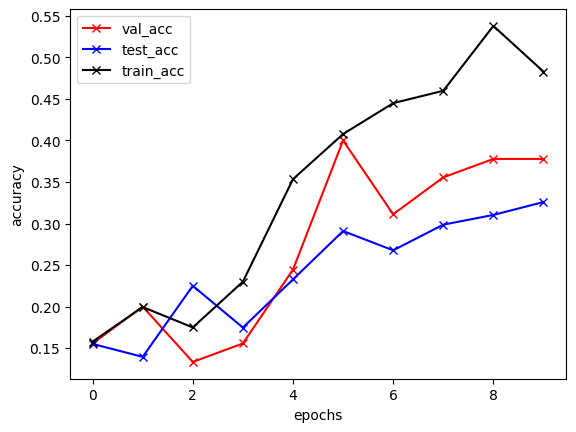

<Figure size 640x480 with 0 Axes>

In [30]:
plt.plot(time, val_acc_my_model, c='red', label='val_acc', marker='x')
plt.plot(time, test_acc_my_model, c='blue', label='test_acc', marker='x')
plt.plot(time, train_acc_my_model, c='black', label='train_acc', marker='x')
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.legend()
plt.show()
plt.savefig('cnn_without_dropout.png')

In [31]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
# Set the model to evaluation mode
def scores(model, dbi_test_dl):
  """
  """
  model.eval()

# Initialize empty lists to store predictions and true labels
  y_pred = []
  y_true = []

  # Iterate over batches in the test dataloader
  for images, labels in dbi_test_dl:
      # Move images and labels to device (GPU/CPU)
      images = images.to(device)
      labels = labels.to(device)

      # Disable gradient computation to speed up inference
      with torch.no_grad():
          # Make predictions
          outputs = model(images)
          # Get predicted labels for each image in the batch
          _, predicted = torch.max(outputs.data, 1)

      # Append predicted and true labels to their respective lists
      y_pred.extend(predicted.cpu().numpy())
      y_true.extend(labels.cpu().numpy())

  # Print classification report and accuracy score
  print(classification_report(y_true, y_pred))
  print("Accuracy:", accuracy_score(y_true, y_pred))
  return accuracy_score(y_true, y_pred)

In [32]:
accurary_cnn = scores(model, dbi_test_dl)
print("Accuracy of CNN model for DBI dataset without droupout:", accurary_cnn)

              precision    recall  f1-score   support

           0       0.40      0.57      0.47        30
           1       0.34      0.32      0.33        31
           2       0.35      0.35      0.35        26
           3       0.52      0.52      0.52        29
           4       0.00      0.00      0.00        36
           5       0.11      0.10      0.11        20
           6       0.38      0.57      0.45        21

    accuracy                           0.34       193
   macro avg       0.30      0.35      0.32       193
weighted avg       0.29      0.34      0.31       193

Accuracy: 0.33678756476683935
Accuracy of CNN model for DBI dataset without droupout: 0.33678756476683935


**With dropout:**

In [33]:
class DropoutDogBreedClassificationCNN(ImageClassificationBase):
    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(


            nn.Conv2d(3, 16, 3, stride=1, padding=1),   # convolutional layer 224 * 224 * 16
            nn.ReLU(),
            nn.BatchNorm2d(16),                         # batch normalization

            nn.Conv2d(16, 16, 3, stride=1, padding=1),  # convolutional layer 224 * 224 * 16
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                         # max pooling (2*2) 112 * 112 * 16

            nn.Conv2d(16, 8, 3, stride=1, padding=1),   # convolutional layer 112 * 112 * 8
            nn.ReLU(),
            nn.BatchNorm2d(8),                          # batch normalization

            nn.Conv2d(8, 8, 3, stride=1, padding=1),    # convolutional layer 112 * 112* 8
            nn.ReLU(),
            nn.MaxPool2d(2,2),                          # max pooling 56 * 56* 8

            nn.Dropout(0.5, inplace=False),             # dropout (0.5)
            nn.Flatten(),
            nn.Linear(56*56*8, 32),                     # fully connected
            nn.ReLU(),
            nn.Linear(32, 7),
            nn.Dropout(0.5, inplace=False),             # dropout (0.5)
            nn.LogSoftmax(dim = 1),                     # softmax
        )

    def forward(self, xb):
        return self.network(xb)

In [34]:
model_dropout = DropoutDogBreedClassificationCNN()
model_dropout

DropoutDogBreedClassificationCNN(
  (network): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(16, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): Conv2d(8, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Dropout(p=0.5, inplace=False)
    (13): Flatten(start_dim=1, end_dim=-1)
    (14): Linear(in_features=25088, out_features=32, bias=True)
    (15): ReLU()
    (16): Linear(in_features=32, out_features=7, bias=True)
    (17): 

In [37]:
model_dropout = to_device(model_dropout, device);

In [38]:
evaluate(model_dropout, dbi_train_dl, dbi_val_dl, dbi_test_dl)

{'val_loss': 1.9547549486160278,
 'val_acc': 0.1130952313542366,
 'test_acc': 0.19362980127334595,
 'train_acc': 0.17777778208255768}

In [39]:
history_model_dropout = fit_one_cycle(num_epochs, max_lr, model_dropout, dbi_train_dl, dbi_val_dl, dbi_test_dl, weight_decay, grad_clip, opt_func)


  0%|          | 0/7 [00:00<?, ?it/s]

Epoch [0] : train_loss: 1.9623, val_loss: 1.9448, val_acc: 0.1556


  0%|          | 0/7 [00:00<?, ?it/s]

Epoch [1] : train_loss: 2.0325, val_loss: 1.9380, val_acc: 0.1778


  0%|          | 0/7 [00:00<?, ?it/s]

...

Epoch [7] : train_loss: 1.8130, val_loss: 1.7969, val_acc: 0.2000


  0%|          | 0/7 [00:00<?, ?it/s]

Epoch [8] : train_loss: 1.8281, val_loss: 1.7879, val_acc: 0.2889


  0%|          | 0/7 [00:00<?, ?it/s]

Epoch [9] : train_loss: 1.8014, val_loss: 1.7788, val_acc: 0.2444


In [40]:
val_loss_model_dropout = []
train_loss_model_dropout = []
val_acc_model_dropout = []
test_acc_model_dropout = []
train_acc_model_dropout = []
time = list(range(len(history_model_dropout)))
for h in history_model_dropout:
    val_loss_model_dropout.append(h['val_loss'])
    train_loss_model_dropout.append(h['train_loss'])
    val_acc_model_dropout.append(h['val_acc'])
    test_acc_model_dropout.append(h['test_acc'])
    train_acc_model_dropout.append(h['train_acc'])

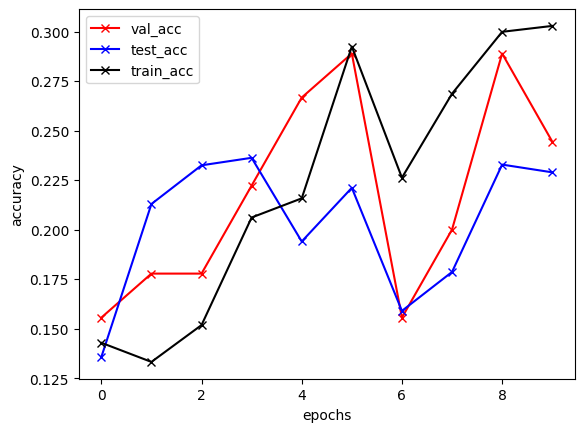

<Figure size 640x480 with 0 Axes>

In [41]:
plt.plot(time, val_acc_model_dropout, c='red', label='val_acc', marker='x')
plt.plot(time, test_acc_model_dropout, c='blue', label='test_acc', marker='x')
plt.plot(time, train_acc_model_dropout, c='black', label='train_acc', marker='x')
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.legend()
plt.show()
plt.savefig('cnn_dropout.png')


In [42]:
accurary_cnn_dropout = scores(model_dropout, dbi_test_dl)
print("Accuracy of CNN model for DBI dataset with droupout:", accurary_cnn_dropout)

              precision    recall  f1-score   support

           0       0.30      0.77      0.43        30
           1       0.00      0.00      0.00        31
           2       0.27      0.15      0.20        26
           3       0.50      0.03      0.06        29
           4       0.09      0.08      0.09        36
           5       0.00      0.00      0.00        20
           6       0.22      0.71      0.34        21

    accuracy                           0.24       193
   macro avg       0.20      0.25      0.16       193
weighted avg       0.20      0.24      0.16       193

Accuracy: 0.23834196891191708
Accuracy of CNN model for DBI dataset with droupout: 0.23834196891191708


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# Task 3: ResNet Training on the DBI


# Task 3: ResNet Training on the DBI


**3a. ResNet-18 model**

In [43]:
class DogBreedResnet18(ImageClassificationBase):
    def __init__(self):
        super().__init__()

        self.network = models.resnet18(pretrained=False)
        # Replace last layer
        num_ftrs = self.network.fc.in_features
        self.network.fc = nn.Sequential(
            nn.Linear(num_ftrs, 7),
            nn.LogSoftmax(dim=1)
        )

    def forward(self, xb):
        return self.network(xb)

In [44]:
resnet18_model_untrained = DogBreedResnet18()

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


In [45]:
resnet18_model_untrained = to_device(resnet18_model_untrained, device);

In [46]:
evaluate(resnet18_model_untrained, dbi_train_dl, dbi_val_dl, dbi_test_dl)

{'val_loss': 1.964535117149353,
 'val_acc': 0.165922611951828,
 'test_acc': 0.15504807233810425,
 'train_acc': 0.2222222238779068}

In [47]:
history_resnet18_model = fit_one_cycle(num_epochs, max_lr, resnet18_model_untrained, dbi_train_dl, dbi_val_dl, dbi_test_dl, weight_decay, grad_clip, opt_func)


  0%|          | 0/7 [00:00<?, ?it/s]

Epoch [0] : train_loss: 1.9819, val_loss: 1.9581, val_acc: 0.1556


  0%|          | 0/7 [00:00<?, ?it/s]

Epoch [1] : train_loss: 1.9718, val_loss: 1.9918, val_acc: 0.1333


  0%|          | 0/7 [00:00<?, ?it/s]

...

Epoch [7] : train_loss: 1.4873, val_loss: 1.8848, val_acc: 0.3556


  0%|          | 0/7 [00:00<?, ?it/s]

Epoch [8] : train_loss: 1.3900, val_loss: 1.8247, val_acc: 0.2889


  0%|          | 0/7 [00:00<?, ?it/s]

Epoch [9] : train_loss: 1.3716, val_loss: 1.7650, val_acc: 0.3111


In [48]:
val_loss_resnet18_model = []
train_loss_resnet18_model = []
val_acc_resnet18_model = []
test_acc_resnet18_model = []
train_acc_resnet18_model = []
time = list(range(len(history_resnet18_model)))
for h in history_resnet18_model:
    val_loss_resnet18_model.append(h['val_loss'])
    train_loss_resnet18_model.append(h['train_loss'])
    val_acc_resnet18_model.append(h['val_acc'])
    test_acc_resnet18_model.append(h['test_acc'])
    train_acc_resnet18_model.append(h['train_acc'])

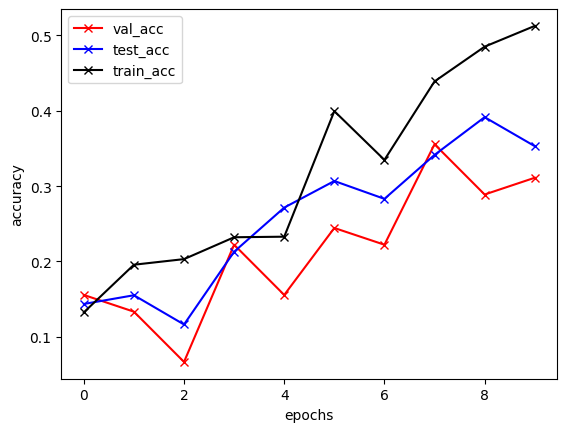

<Figure size 640x480 with 0 Axes>

In [49]:
plt.plot(time, val_acc_resnet18_model, c='red', label='val_acc', marker='x')
plt.plot(time, test_acc_resnet18_model, c='blue', label='test_acc', marker='x')
plt.plot(time, train_acc_resnet18_model, c='black', label='train_acc', marker='x')
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.legend()
plt.show()
plt.savefig('resnet18_untrained.png')

In [50]:
scores(resnet18_model_untrained, dbi_test_dl)

              precision    recall  f1-score   support

           0       0.39      0.37      0.38        30
           1       0.37      0.58      0.45        31
           2       0.11      0.08      0.09        26
           3       0.64      0.62      0.63        29
           4       0.25      0.08      0.12        36
           5       0.38      0.25      0.30        20
           6       0.31      0.67      0.42        21

    accuracy                           0.37       193
   macro avg       0.35      0.38      0.34       193
weighted avg       0.35      0.37      0.34       193

Accuracy: 0.36787564766839376


0.36787564766839376

3b. previous model on SDD dataset

Run the trained model on the entire SDD dataset and report the accuracy.
Compare the accuracy obtained on the (test set of) DBI, vs. the accuracy obtained on the
SDD. Which is higher? Why do you think that might be? Explain very briefly, in one or two
sentences.

In [52]:
accuracy_sdd = scores(resnet18_model_untrained, SDD_dl)

              precision    recall  f1-score   support

           0       0.27      0.22      0.24       218
           1       0.26      0.43      0.33       150
           2       0.11      0.05      0.07       152
           3       0.39      0.65      0.48       150
           4       0.23      0.13      0.17       171
           5       0.26      0.09      0.13       200
           6       0.30      0.49      0.37       192

    accuracy                           0.29      1233
   macro avg       0.26      0.30      0.26      1233
weighted avg       0.26      0.29      0.25      1233

Accuracy: 0.28629359286293593


It is easily obeserved that the model has better accuracy on the test set of DBI than the whole set of SDD.

The ResNet-18 model performs better on the DBI dataset due to its uniformity and controlled conditions, allowing the model to learn specific patterns easily. However, its generalization ability weakens on the more varied and complex SDD dataset, leading to lower accuracy.

# Task 4: Fine-tuning on the DBI


**ResNet18(Pretrained)**


In [53]:
class DogBreedResnet18Pretrained(ImageClassificationBase):
    def __init__(self):
        super().__init__()

        self.network = models.resnet18(pretrained=True)
        # Replace last layer
        num_ftrs = self.network.fc.in_features
        self.network.fc = nn.Sequential(
            nn.Linear(num_ftrs, 7),
            nn.LogSoftmax(dim=1)
        )

    def forward(self, xb):
        return self.network(xb)

In [54]:
resnet18_pretrained_model = DogBreedResnet18Pretrained()
resnet18_pretrained_model

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 163MB/s]


DogBreedResnet18Pretrained(
  (network): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, aff

In [55]:
resnet18_pretrained_model = to_device(resnet18_pretrained_model, device);

In [56]:
evaluate(resnet18_pretrained_model, dbi_train_dl, dbi_val_dl, dbi_test_dl)

{'val_loss': 2.0823259353637695,
 'val_acc': 0.101190485060215,
 'test_acc': 0.0698317289352417,
 'train_acc': 0.04444444552063942}

In [57]:
history_resnet18_pretrained_model = fit_one_cycle(num_epochs, max_lr, resnet18_pretrained_model, dbi_train_dl, dbi_val_dl, dbi_test_dl, weight_decay, grad_clip, opt_func)

  0%|          | 0/7 [00:00<?, ?it/s]

Epoch [0] : train_loss: 2.0394, val_loss: 1.7500, val_acc: 0.3556


  0%|          | 0/7 [00:00<?, ?it/s]

Epoch [1] : train_loss: 1.1142, val_loss: 0.5247, val_acc: 0.8667


  0%|          | 0/7 [00:00<?, ?it/s]

...

Epoch [7] : train_loss: 0.0291, val_loss: 0.0660, val_acc: 0.9778


  0%|          | 0/7 [00:00<?, ?it/s]

Epoch [8] : train_loss: 0.0248, val_loss: 0.0561, val_acc: 0.9778


  0%|          | 0/7 [00:00<?, ?it/s]

Epoch [9] : train_loss: 0.0209, val_loss: 0.0514, val_acc: 1.0000


In [58]:
accuracy_dbi_resnet18 = scores(resnet18_pretrained_model, dbi_test_dl)
print("Accuracy of Resnet18 on DBI test dataset :", accuracy_dbi_resnet18)
accuracy_sdd_resnet18 = scores(resnet18_pretrained_model, SDD_dl)
print("\n Accuracy of Resnet18 on SDD entire dataset :", accuracy_sdd_resnet18)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        30
           1       1.00      1.00      1.00        31
           2       0.96      0.96      0.96        26
           3       0.96      0.90      0.93        29
           4       0.90      0.97      0.93        36
           5       1.00      1.00      1.00        20
           6       1.00      0.95      0.98        21

    accuracy                           0.97       193
   macro avg       0.97      0.97      0.97       193
weighted avg       0.97      0.97      0.97       193

Accuracy: 0.9689119170984456
Accuracy of Resnet18 on DBI test dataset : 0.9689119170984456
              precision    recall  f1-score   support

           0       0.98      0.94      0.96       218
           1       0.90      0.94      0.92       150
           2       0.93      0.86      0.89       152
           3       0.93      0.82      0.87       150
           4       0.71      0.95      0.

In [59]:
val_loss_resnet18_pretrained_model = []
train_loss_resnet18_pretrained_model = []
val_acc_resnet18_pretrained_model = []
test_acc_resnet18_pretrained_model = []
train_acc_resnet18_pretrained_model = []
time = list(range(len(history_resnet18_pretrained_model)))
for h in history_resnet18_pretrained_model:
    val_loss_resnet18_pretrained_model.append(h['val_loss'])
    train_loss_resnet18_pretrained_model.append(h['train_loss'])
    val_acc_resnet18_pretrained_model.append(h['val_acc'])
    test_acc_resnet18_pretrained_model.append(h['test_acc'])
    train_acc_resnet18_pretrained_model.append(h['train_acc'])

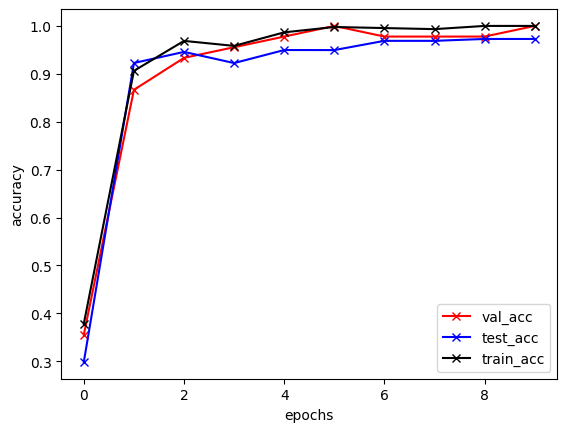

<Figure size 640x480 with 0 Axes>

In [60]:
plt.plot(time, val_acc_resnet18_pretrained_model, c='red', label='val_acc', marker='x')
plt.plot(time, test_acc_resnet18_pretrained_model, c='blue', label='test_acc', marker='x')
plt.plot(time, train_acc_resnet18_pretrained_model, c='black', label='train_acc', marker='x')
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.legend()
plt.show()
plt.savefig('Resnet18_pretrained.png')

**ResNet34 (Pretrained)**

In [61]:
class DogBreedResnet34Pretrained(ImageClassificationBase):
    def __init__(self):
        super().__init__()

        self.network = models.resnet34(pretrained=True)
        # Replace last layer
        num_ftrs = self.network.fc.in_features
        self.network.fc = nn.Sequential(
            nn.Linear(num_ftrs, 7),
            nn.LogSoftmax(dim=1)
        )

    def forward(self, xb):
        return self.network(xb)

In [62]:
resnet34_pretrained_model = DogBreedResnet34Pretrained()
resnet34_pretrained_model

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet34_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet34_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth
100%|██████████| 83.3M/83.3M [00:00<00:00, 204MB/s]


DogBreedResnet34Pretrained(
  (network): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, aff

In [63]:
resnet34_pretrained_model = to_device(resnet34_pretrained_model, device);

In [64]:
evaluate(resnet34_pretrained_model, dbi_train_dl, dbi_val_dl, dbi_test_dl)

{'val_loss': 2.1373443603515625,
 'val_acc': 0.1421130895614624,
 'test_acc': 0.18179085850715637,
 'train_acc': 0.13333334028720856}

In [65]:
history_resnet34_pretrained_model = fit_one_cycle(num_epochs, max_lr, resnet34_pretrained_model, dbi_train_dl, dbi_val_dl, dbi_test_dl, weight_decay, grad_clip, opt_func)

  0%|          | 0/7 [00:00<?, ?it/s]

Epoch [0] : train_loss: 1.9704, val_loss: 1.5689, val_acc: 0.4222


  0%|          | 0/7 [00:00<?, ?it/s]

Epoch [1] : train_loss: 0.9479, val_loss: 0.1931, val_acc: 1.0000


  0%|          | 0/7 [00:00<?, ?it/s]

...

Epoch [7] : train_loss: 0.0299, val_loss: 0.0743, val_acc: 0.9778


  0%|          | 0/7 [00:00<?, ?it/s]

Epoch [8] : train_loss: 0.0137, val_loss: 0.0570, val_acc: 0.9778


  0%|          | 0/7 [00:00<?, ?it/s]

Epoch [9] : train_loss: 0.0141, val_loss: 0.0591, val_acc: 0.9778


In [66]:
accuracy_dbi_resnet34 = scores(resnet34_pretrained_model, dbi_test_dl)
print("Accuracy of Resnet34 on DBI test dataset :", accuracy_dbi_resnet34)
accuracy_sdd_resnet34 = scores(resnet34_pretrained_model, SDD_dl)
print("\n Accuracy of Resnet34 on SDD entire dataset :", accuracy_sdd_resnet34)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        30
           1       1.00      1.00      1.00        31
           2       1.00      1.00      1.00        26
           3       0.93      0.97      0.95        29
           4       0.97      0.94      0.96        36
           5       1.00      1.00      1.00        20
           6       1.00      1.00      1.00        21

    accuracy                           0.98       193
   macro avg       0.99      0.99      0.99       193
weighted avg       0.98      0.98      0.98       193

Accuracy: 0.9844559585492227
Accuracy of Resnet34 on DBI test dataset : 0.9844559585492227
              precision    recall  f1-score   support

           0       0.98      0.96      0.97       218
           1       0.96      0.91      0.94       150
           2       0.86      0.90      0.88       152
           3       0.92      0.93      0.92       150
           4       0.85      0.92      0.

In [67]:
val_loss_resnet34_pretrained_model = []
train_loss_resnet34_pretrained_model = []
val_acc_resnet34_pretrained_model = []
test_acc_resnet34_pretrained_model = []
train_acc_resnet34_pretrained_model = []
time = list(range(len(history_resnet34_pretrained_model)))
for h in history_resnet34_pretrained_model:
    val_loss_resnet34_pretrained_model.append(h['val_loss'])
    train_loss_resnet34_pretrained_model.append(h['train_loss'])
    val_acc_resnet34_pretrained_model.append(h['val_acc'])
    test_acc_resnet34_pretrained_model.append(h['test_acc'])
    train_acc_resnet34_pretrained_model.append(h['train_acc'])

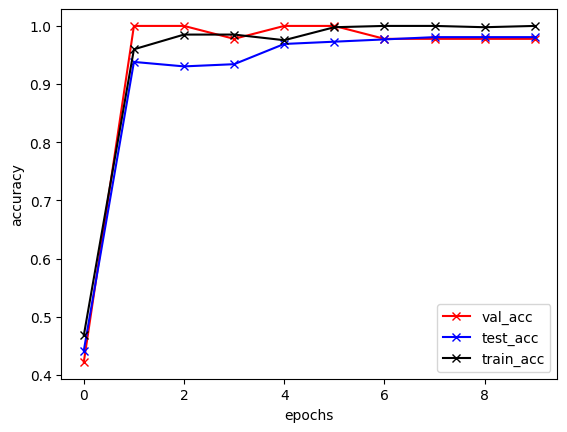

<Figure size 640x480 with 0 Axes>

In [68]:
plt.plot(time, val_acc_resnet34_pretrained_model, c='red', label='val_acc', marker='x')
plt.plot(time, test_acc_resnet34_pretrained_model, c='blue', label='test_acc', marker='x')
plt.plot(time, train_acc_resnet34_pretrained_model, c='black', label='train_acc', marker='x')
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.legend()
plt.show()
plt.savefig('Resnet34_pretrained.png')

**ResNeXt50 (Pretrained)**

In [73]:
class DogBreedResNeXt50Pretrained(ImageClassificationBase):
    def __init__(self):
        super().__init__()

        self.network = models.resnext50_32x4d(pretrained=True)
        # Replace last layer
        num_ftrs = self.network.fc.in_features
        self.network.fc = nn.Sequential(
            nn.Linear(num_ftrs, 7),
            nn.LogSoftmax(dim=1)
        )

    def forward(self, xb):
        return self.network(xb)

In [74]:
resneXt50_pretrained_model = DogBreedResNeXt50Pretrained()
resneXt50_pretrained_model

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNeXt50_32X4D_Weights.IMAGENET1K_V1`. You can also use `weights=ResNeXt50_32X4D_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnext50_32x4d-7cdf4587.pth" to /root/.cache/torch/hub/checkpoints/resnext50_32x4d-7cdf4587.pth
100%|██████████| 95.8M/95.8M [00:00<00:00, 185MB/s]


DogBreedResNeXt50Pretrained(
  (network): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
        (bn2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(128, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
       

In [75]:
resneXt50_pretrained_model = to_device(resneXt50_pretrained_model, device);

In [76]:
evaluate(resneXt50_pretrained_model, dbi_train_dl, dbi_val_dl, dbi_test_dl)

{'val_loss': 2.0702731609344482,
 'val_acc': 0.0401785708963871,
 'test_acc': 0.042608171701431274,
 'train_acc': 0.02222222276031971}

In [77]:
history_resneXt50_pretrained_model = fit_one_cycle(num_epochs, max_lr, resneXt50_pretrained_model, dbi_train_dl, dbi_val_dl, dbi_test_dl, weight_decay, grad_clip, opt_func)

  0%|          | 0/7 [00:00<?, ?it/s]

Epoch [0] : train_loss: 1.9297, val_loss: 1.5117, val_acc: 0.5778


  0%|          | 0/7 [00:00<?, ?it/s]

Epoch [1] : train_loss: 0.8954, val_loss: 0.1154, val_acc: 1.0000


  0%|          | 0/7 [00:00<?, ?it/s]

...

Epoch [7] : train_loss: 0.0228, val_loss: 0.0384, val_acc: 0.9778


  0%|          | 0/7 [00:00<?, ?it/s]

Epoch [8] : train_loss: 0.0142, val_loss: 0.0349, val_acc: 0.9778


  0%|          | 0/7 [00:00<?, ?it/s]

Epoch [9] : train_loss: 0.0087, val_loss: 0.0337, val_acc: 0.9778


In [78]:
accuracy_dbi_resneXt50 = scores(resneXt50_pretrained_model, dbi_test_dl)
print("Accuracy of ResNeXt50 on DBI test dataset :", accuracy_dbi_resneXt50)
accuracy_sdd_resneXt50 = scores(resneXt50_pretrained_model, SDD_dl)
print("\n Accuracy of ResNeXt50 on SDD entire dataset :", accuracy_sdd_resneXt50)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        30
           1       1.00      1.00      1.00        31
           2       0.93      1.00      0.96        26
           3       0.93      0.97      0.95        29
           4       0.97      0.92      0.94        36
           5       1.00      1.00      1.00        20
           6       1.00      0.95      0.98        21

    accuracy                           0.97       193
   macro avg       0.98      0.98      0.98       193
weighted avg       0.97      0.97      0.97       193

Accuracy: 0.9740932642487047
Accuracy of ResNeXt50 on DBI test dataset : 0.9740932642487047
              precision    recall  f1-score   support

           0       0.99      0.97      0.98       218
           1       0.94      0.95      0.94       150
           2       0.82      0.97      0.89       152
           3       0.89      0.89      0.89       150
           4       0.87      0.93      0

In [79]:
val_loss_resneXt50_pretrained_model = []
train_loss_resneXt50_pretrained_model = []
val_acc_resneXt50_pretrained_model = []
test_acc_resneXt50_pretrained_model = []
train_acc_resneXt50_pretrained_model = []
time = list(range(len(history_resneXt50_pretrained_model)))
for h in history_resneXt50_pretrained_model:
    val_loss_resneXt50_pretrained_model.append(h['val_loss'])
    train_loss_resneXt50_pretrained_model.append(h['train_loss'])
    val_acc_resneXt50_pretrained_model.append(h['val_acc'])
    test_acc_resneXt50_pretrained_model.append(h['test_acc'])
    train_acc_resneXt50_pretrained_model.append(h['train_acc'])

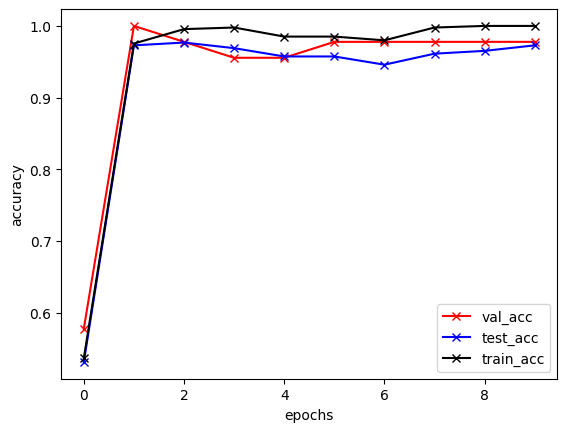

<Figure size 640x480 with 0 Axes>

In [80]:
plt.plot(time, val_acc_resneXt50_pretrained_model, c='red', label='val_acc', marker='x')
plt.plot(time, test_acc_resneXt50_pretrained_model, c='blue', label='test_acc', marker='x')
plt.plot(time, train_acc_resneXt50_pretrained_model, c='black', label='train_acc', marker='x')
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.legend()
plt.show()
plt.savefig('ResNeXt50_pretrained.png')

**SwinTransformer (Tiny)**

In [83]:
class DogBreedSwinTinyPretrained(ImageClassificationBase):
    def __init__(self):
        super().__init__()

        self.network = models.swin_t(pretrained=True)
        # Replace last layer
        num_ftrs = self.network.head.in_features
        self.network.head = nn.Sequential(
            nn.Linear(num_ftrs, 7),
            nn.LogSoftmax(dim=1)
        )

    def forward(self, xb):
        return self.network(xb)

In [84]:
swin_t_pretrained_model = DogBreedSwinTinyPretrained()
swin_t_pretrained_model

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=Swin_T_Weights.IMAGENET1K_V1`. You can also use `weights=Swin_T_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


DogBreedSwinTinyPretrained(
  (network): SwinTransformer(
    (features): Sequential(
      (0): Sequential(
        (0): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
        (1): Permute()
        (2): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
      )
      (1): Sequential(
        (0): SwinTransformerBlock(
          (norm1): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
          (attn): ShiftedWindowAttention(
            (qkv): Linear(in_features=96, out_features=288, bias=True)
            (proj): Linear(in_features=96, out_features=96, bias=True)
          )
          (stochastic_depth): StochasticDepth(p=0.0, mode=row)
          (norm2): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
          (mlp): MLP(
            (0): Linear(in_features=96, out_features=384, bias=True)
            (1): GELU(approximate='none')
            (2): Dropout(p=0.0, inplace=False)
            (3): Linear(in_features=384, out_features=96, bias=True)
            (4): Dropo

In [85]:
swin_t_pretrained_model = to_device(swin_t_pretrained_model, device);

In [86]:
evaluate(swin_t_pretrained_model, dbi_train_dl, dbi_val_dl, dbi_test_dl)

{'val_loss': 1.9710252285003662,
 'val_acc': 0.0803571417927742,
 'test_acc': 0.07361778616905212,
 'train_acc': 0.13333334028720856}

In [87]:
history_swin_t_pretrained_model = fit_one_cycle(num_epochs, max_lr, swin_t_pretrained_model, dbi_train_dl, dbi_val_dl, dbi_test_dl, weight_decay, grad_clip, opt_func)

  0%|          | 0/7 [00:00<?, ?it/s]

Epoch [0] : train_loss: 1.9339, val_loss: 1.8144, val_acc: 0.4000


  0%|          | 0/7 [00:00<?, ?it/s]

Epoch [1] : train_loss: 1.4076, val_loss: 0.4115, val_acc: 0.9333


  0%|          | 0/7 [00:00<?, ?it/s]

...

Epoch [7] : train_loss: 0.1291, val_loss: 0.2875, val_acc: 0.8889


  0%|          | 0/7 [00:00<?, ?it/s]

Epoch [8] : train_loss: 0.0866, val_loss: 0.2302, val_acc: 0.8889


  0%|          | 0/7 [00:00<?, ?it/s]

Epoch [9] : train_loss: 0.0933, val_loss: 0.2226, val_acc: 0.8889


In [88]:
accuracy_dbi_swin_t = scores(swin_t_pretrained_model, dbi_test_dl)
print("Accuracy of SwinTiny on DBI test dataset :", accuracy_dbi_swin_t)
accuracy_sdd_swin_t = scores(swin_t_pretrained_model, SDD_dl)
print("\n Accuracy of SwinTiny on SDD entire dataset :", accuracy_sdd_swin_t)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        30
           1       0.97      1.00      0.98        31
           2       0.92      0.92      0.92        26
           3       0.89      0.86      0.88        29
           4       0.89      0.89      0.89        36
           5       1.00      1.00      1.00        20
           6       0.95      0.95      0.95        21

    accuracy                           0.94       193
   macro avg       0.95      0.95      0.95       193
weighted avg       0.94      0.94      0.94       193

Accuracy: 0.9430051813471503
Accuracy of SwinTiny on DBI test dataset : 0.9430051813471503
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       218
           1       0.96      0.91      0.93       150
           2       0.95      0.86      0.90       152
           3       0.81      0.85      0.83       150
           4       0.78      0.84      0.

In [89]:
val_loss_swin_t_pretrained_model = []
train_loss_swin_t_pretrained_model = []
val_acc_swin_t_pretrained_model = []
test_acc_swin_t_pretrained_model = []
train_acc_swin_t_pretrained_model = []
time = list(range(len(history_swin_t_pretrained_model)))
for h in history_swin_t_pretrained_model:
    val_loss_swin_t_pretrained_model.append(h['val_loss'])
    train_loss_swin_t_pretrained_model.append(h['train_loss'])
    val_acc_swin_t_pretrained_model.append(h['val_acc'])
    test_acc_swin_t_pretrained_model.append(h['test_acc'])
    train_acc_swin_t_pretrained_model.append(h['train_acc'])

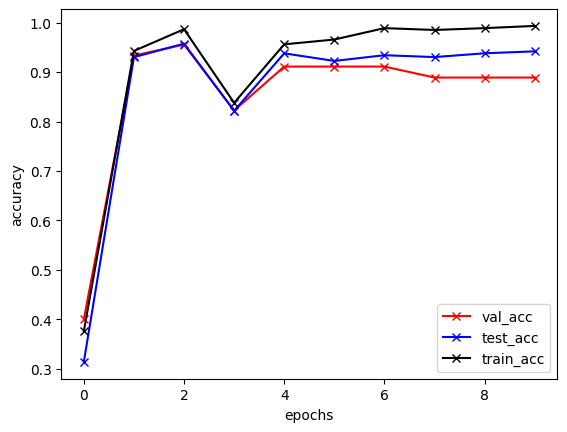

<Figure size 640x480 with 0 Axes>

In [90]:
plt.plot(time, val_acc_swin_t_pretrained_model, c='red', label='val_acc', marker='x')
plt.plot(time, test_acc_swin_t_pretrained_model, c='blue', label='test_acc', marker='x')
plt.plot(time, train_acc_swin_t_pretrained_model, c='black', label='train_acc', marker='x')
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.legend()
plt.show()
plt.savefig('SwinTiny_pretrained.png')

Fifth model chose from torchvision: **DenseNet121**

In [91]:
class DogBreedDenseNet121Pretrained(ImageClassificationBase):
    def __init__(self):
        super().__init__()

        self.network = models.densenet121(pretrained=True)
        # Replace last layer
        num_ftrs = self.network.classifier.in_features
        self.network.classifier = nn.Sequential(
            nn.Linear(num_ftrs, 7),
            nn.LogSoftmax(dim=1)
        )

    def forward(self, xb):
        return self.network(xb)

In [92]:
densenet121_pretrained_model = DogBreedDenseNet121Pretrained()
densenet121_pretrained_model

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth
100%|██████████| 30.8M/30.8M [00:00<00:00, 148MB/s]


DogBreedDenseNet121Pretrained(
  (network): DenseNet(
    (features): Sequential(
      (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu0): ReLU(inplace=True)
      (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (denseblock1): _DenseBlock(
        (denselayer1): _DenseLayer(
          (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu1): ReLU(inplace=True)
          (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu2): ReLU(inplace=True)
          (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        )
        (denselayer2): _DenseLayer(
          (norm1): BatchNorm2d(96, e

In [93]:
densenet121_pretrained_model = to_device(densenet121_pretrained_model, device);

In [94]:
evaluate(densenet121_pretrained_model, dbi_train_dl, dbi_val_dl, dbi_test_dl)

{'val_loss': 2.047776460647583,
 'val_acc': 0.101934514939785,
 'test_acc': 0.10817307978868484,
 'train_acc': 0.15555556118488312}

In [95]:
history_densenet121_pretrained_model = fit_one_cycle(num_epochs, max_lr, densenet121_pretrained_model, dbi_train_dl, dbi_val_dl, dbi_test_dl, weight_decay, grad_clip, opt_func)

  0%|          | 0/7 [00:00<?, ?it/s]

Epoch [0] : train_loss: 2.0365, val_loss: 1.8020, val_acc: 0.2889


  0%|          | 0/7 [00:00<?, ?it/s]

Epoch [1] : train_loss: 1.1762, val_loss: 0.4390, val_acc: 0.9111


  0%|          | 0/7 [00:00<?, ?it/s]

...

Epoch [7] : train_loss: 0.0199, val_loss: 0.0495, val_acc: 0.9778


  0%|          | 0/7 [00:00<?, ?it/s]

Epoch [8] : train_loss: 0.0120, val_loss: 0.0516, val_acc: 0.9778


  0%|          | 0/7 [00:00<?, ?it/s]

Epoch [9] : train_loss: 0.0186, val_loss: 0.0549, val_acc: 0.9778


In [96]:
accuracy_dbi_densenet121 = scores(densenet121_pretrained_model, dbi_test_dl)
print("Accuracy of DenseNet121 on DBI test dataset :", accuracy_dbi_densenet121)
accuracy_sdd_densenet121 = scores(densenet121_pretrained_model, SDD_dl)
print("\n Accuracy of DenseNet121 on SDD entire dataset :", accuracy_sdd_densenet121)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        30
           1       1.00      1.00      1.00        31
           2       0.96      0.96      0.96        26
           3       0.85      1.00      0.92        29
           4       1.00      0.89      0.94        36
           5       1.00      1.00      1.00        20
           6       1.00      0.95      0.98        21

    accuracy                           0.97       193
   macro avg       0.97      0.97      0.97       193
weighted avg       0.97      0.97      0.97       193

Accuracy: 0.9689119170984456
Accuracy of DenseNet121 on DBI test dataset : 0.9689119170984456
              precision    recall  f1-score   support

           0       0.98      0.94      0.96       218
           1       0.92      0.95      0.93       150
           2       0.94      0.89      0.92       152
           3       0.90      0.92      0.91       150
           4       0.87      0.88     

In [97]:
val_loss_densenet121_pretrained_model = []
train_loss_densenet121_pretrained_model = []
val_acc_densenet121_pretrained_model = []
test_acc_densenet121_pretrained_model = []
train_acc_densenet121_pretrained_model = []
time = list(range(len(history_densenet121_pretrained_model)))
for h in history_densenet121_pretrained_model:
    val_loss_densenet121_pretrained_model.append(h['val_loss'])
    train_loss_densenet121_pretrained_model.append(h['train_loss'])
    val_acc_densenet121_pretrained_model.append(h['val_acc'])
    test_acc_densenet121_pretrained_model.append(h['test_acc'])
    train_acc_densenet121_pretrained_model.append(h['train_acc'])

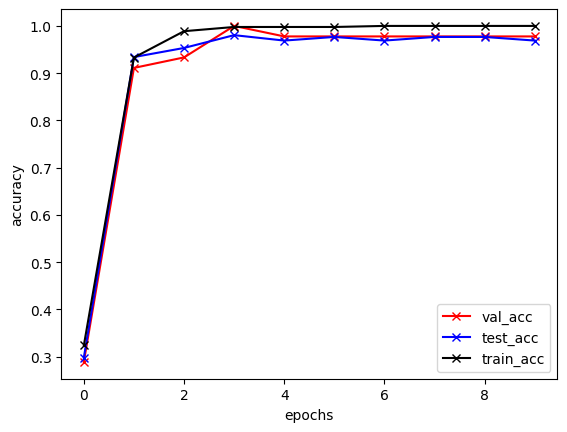

<Figure size 640x480 with 0 Axes>

In [98]:
plt.plot(time, val_acc_densenet121_pretrained_model, c='red', label='val_acc', marker='x')
plt.plot(time, test_acc_densenet121_pretrained_model, c='blue', label='test_acc', marker='x')
plt.plot(time, train_acc_densenet121_pretrained_model, c='black', label='train_acc', marker='x')
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.legend()
plt.show()
plt.savefig('DenseNet121_pretrained.png')

In [100]:
print(f"ResNet18 (Untrained): DBI - {scores(resnet18_model_untrained, dbi_test_dl):.4f}, SDD - {accuracy_sdd:.4f}")
print(f"ResNet18 (Pretrained): DBI - {accuracy_dbi_resnet18:.4f}, SDD - {accuracy_sdd_resnet18:.4f}")
print(f"ResNet34 (Pretrained): DBI - {accuracy_dbi_resnet34:.4f}, SDD - {accuracy_sdd_resnet34:.4f}")
print(f"ResNeXt50 (Pretrained): DBI - {accuracy_dbi_resneXt50:.4f}, SDD - {accuracy_sdd_resneXt50:.4f}")
print(f"SwinTransformer (Tiny): DBI - {accuracy_dbi_swin_t:.4f}, SDD - {accuracy_sdd_swin_t:.4f}")
print(f"DenseNet121 (Pretrained): DBI - {accuracy_dbi_densenet121:.4f}, SDD - {accuracy_sdd_densenet121:.4f}")

              precision    recall  f1-score   support

           0       0.39      0.37      0.38        30
           1       0.37      0.58      0.45        31
           2       0.11      0.08      0.09        26
           3       0.64      0.62      0.63        29
           4       0.25      0.08      0.12        36
           5       0.38      0.25      0.30        20
           6       0.31      0.67      0.42        21

    accuracy                           0.37       193
   macro avg       0.35      0.38      0.34       193
weighted avg       0.35      0.37      0.34       193

Accuracy: 0.36787564766839376
ResNet18 (Untrained): DBI - 0.3679, SDD - 0.2863
ResNet18 (Pretrained): DBI - 0.9689, SDD - 0.9035
ResNet34 (Pretrained): DBI - 0.9845, SDD - 0.9303
ResNeXt50 (Pretrained): DBI - 0.9741, SDD - 0.9311
SwinTransformer (Tiny): DBI - 0.9430, SDD - 0.9059
DenseNet121 (Pretrained): DBI - 0.9689, SDD - 0.9327
